In [5]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.noise_scheduler import LinearNoiseScheduler

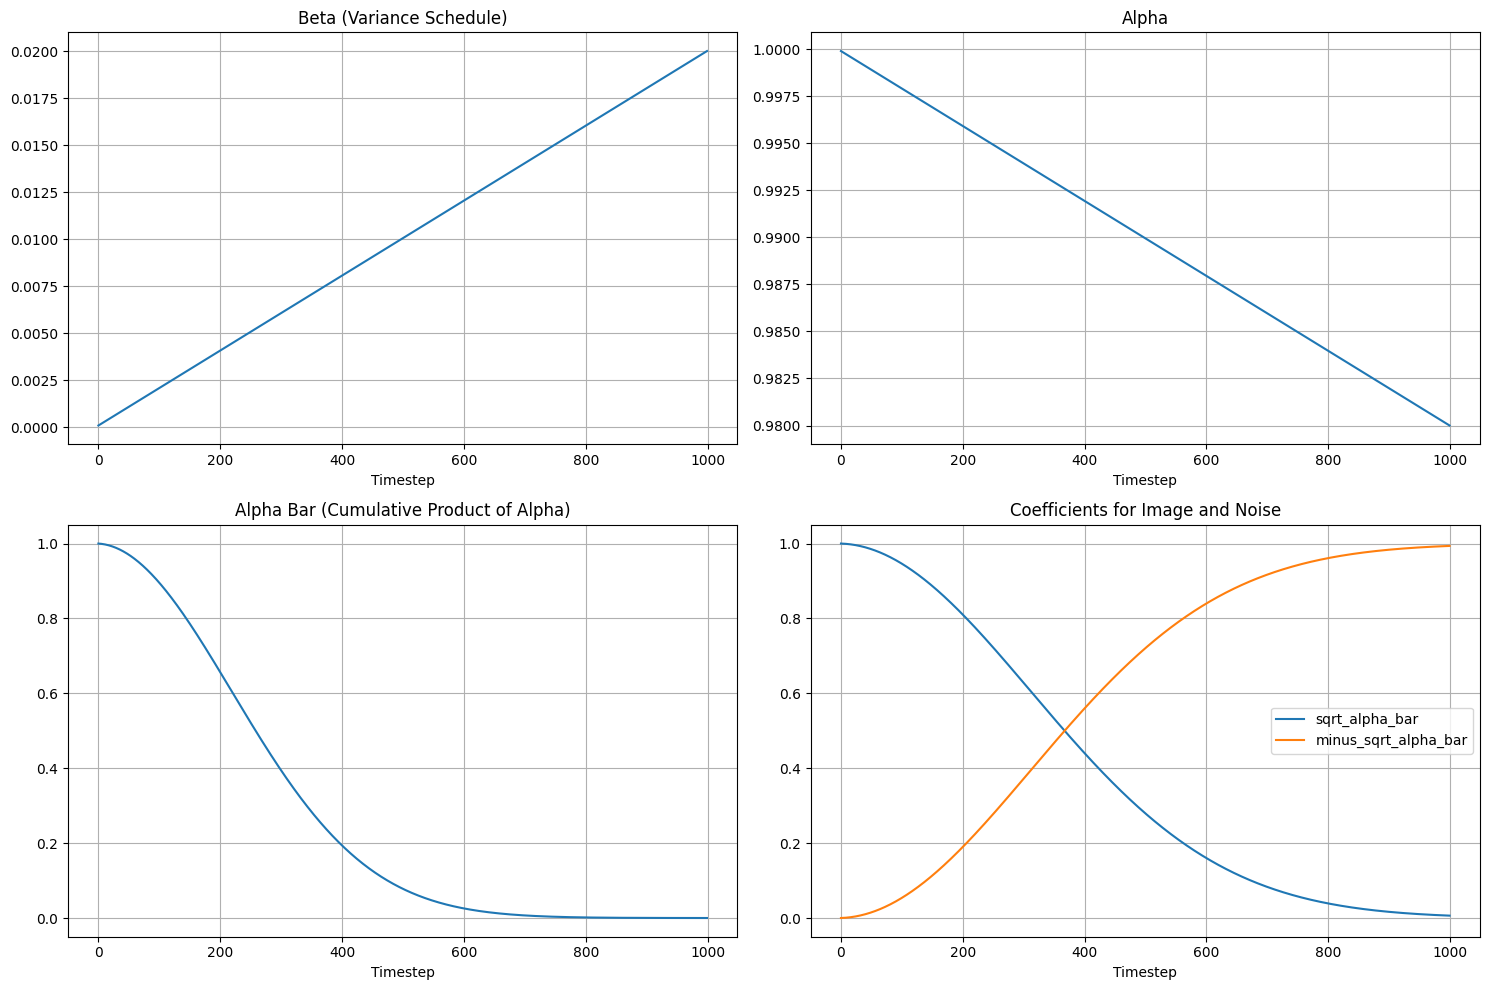

In [6]:
total_steps = 1000
beta_start = 1e-4
beta_end = 0.02
scheduler = LinearNoiseScheduler(beta_start, beta_end, total_steps)

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

axs[0, 0].plot(scheduler.beta.numpy())
axs[0, 0].set_title("Beta (Variance Schedule)")
axs[0, 0].set_xlabel("Timestep")
axs[0, 0].grid(True)

axs[0, 1].plot(scheduler.alpha.numpy())
axs[0, 1].set_title("Alpha")
axs[0, 1].set_xlabel("Timestep")
axs[0, 1].grid(True)

axs[1, 0].plot(scheduler.alpha_bar.numpy())
axs[1, 0].set_title("Alpha Bar (Cumulative Product of Alpha)")
axs[1, 0].set_xlabel("Timestep")
axs[1, 0].grid(True)

axs[1, 1].plot(scheduler.sqrt_alpha_bar.numpy(), label='sqrt_alpha_bar')
axs[1, 1].plot(scheduler.minus_sqrt_alpha_bar.numpy(), label='minus_sqrt_alpha_bar')
axs[1, 1].set_title("Coefficients for Image and Noise")
axs[1, 1].set_xlabel("Timestep")
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

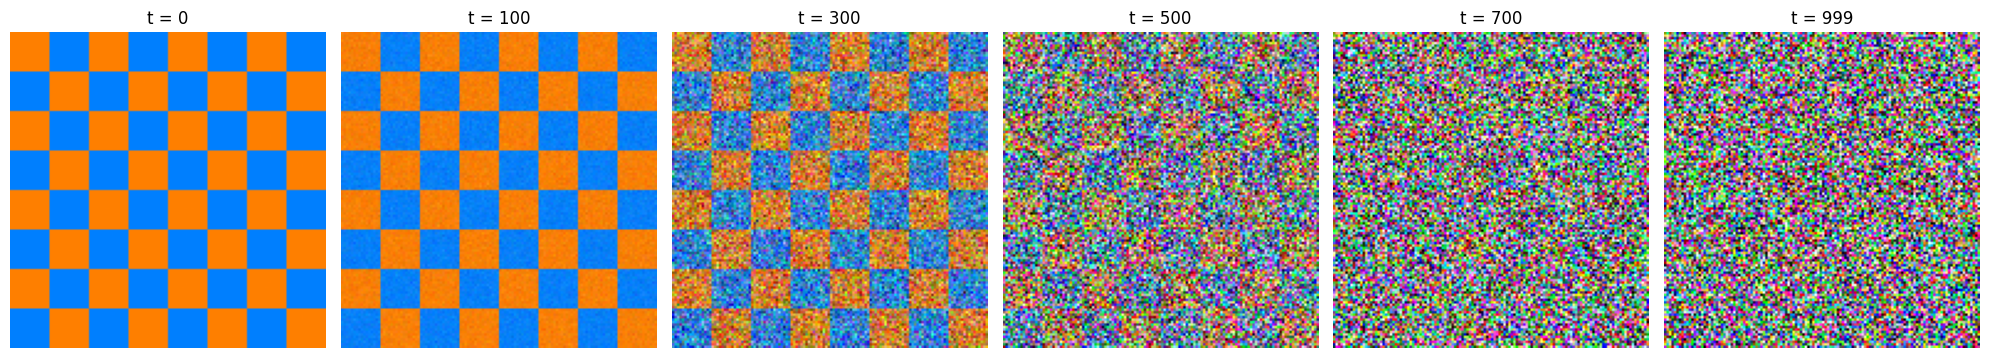

In [7]:
def generate_checkerboard(size=128, squares=8):
    image = np.zeros((size, size, 3), dtype=np.float32)
    square_size = size // squares
    for i in range(squares):
        for j in range(squares):
            if (i + j) % 2 == 0:
                image[i*square_size:(i+1)*square_size, j*square_size:(j+1)*square_size] = [1.0, 0.5, 0.0]
            else:
                image[i*square_size:(i+1)*square_size, j*square_size:(j+1)*square_size] = [0.0, 0.5, 1.0]
    
    img_tensor = torch.tensor(image).float()
    img_tensor = img_tensor.permute(2, 0, 1)
    img_tensor = img_tensor * 2.0 - 1.0
    return img_tensor

def tensor_to_image(tensor):
    tensor = (tensor + 1.0) / 2.0
    tensor = tensor.clamp(0, 1)
    tensor = tensor.permute(1, 2, 0)
    return tensor.numpy()

img_tensor = generate_checkerboard()

timesteps = [0, 100, 300, 500, 700, 999]
plt.figure(figsize=(20, 4))

for i, t in enumerate(timesteps):
    noised_img_tensor = scheduler.noise(img_tensor, t)
    noised_img = tensor_to_image(noised_img_tensor)
    
    plt.subplot(1, len(timesteps), i + 1)
    plt.imshow(noised_img)
    plt.title(f"t = {t}")
    plt.axis("off")

plt.tight_layout()
plt.show()